# Using ECCC data to generate percentile temperature regressions for Vancouver and Toronto
similar to the Hawkins et al 2026 paper: https://rmets.onlinelibrary.wiley.com/doi/full/10.1002/wea.70062

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import requests

from cartopy import crs as ccrs, feature as cfeature
import netCDF4
from netCDF4 import Dataset
from datetime import datetime as dt

import scipy.stats as stats
from sklearn import linear_model
import statsmodels.api as sm
import seaborn as sns

from env_canada import ECHistorical
from env_canada.ec_historical import get_historical_stations
import asyncio

In [ ]:
# trying the env_canada package from https://pypi.org/project/env_canada/
!pip install env_canada

## testing the env_canada package functions for a Vancouver station

In [48]:
# ec = ECHistoricalRange(
#     station_id=1108395,
#     timeframe="daily",
#     daterange=(dt(2000,1,1), dt(2025,12,31)),
# )

ec_en_csv = ECHistorical(station_id=1108395, year=2020, language="english", format="csv")

await ec_en_csv.update()
#await ec.get_data()

df2020 = pd.read_csv(ec_en_csv.station_data)

#df = pd.read_csv(ec.csv)

In [49]:
ec_en_csv = ECHistorical(station_id=1108395, year=2021, language="english", format="csv")

await ec_en_csv.update()
#await ec.get_data()

df2021 = pd.read_csv(ec_en_csv.station_data)

In [54]:
df = pd.concat([df2020, df2021], ignore_index=True)

In [55]:
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.19,VANCOUVER INTL A,1108395,2020-01-01,2020,1,1,NaN,10.7,...,0.0,NaN,0.8,NaN,NaN,NaN,27.0,NaN,68.0,NaN
1,-123.18,49.19,VANCOUVER INTL A,1108395,2020-01-02,2020,1,2,NaN,6.3,...,0.0,NaN,8.0,NaN,NaN,NaN,25.0,NaN,61.0,NaN
2,-123.18,49.19,VANCOUVER INTL A,1108395,2020-01-03,2020,1,3,NaN,12.0,...,0.0,NaN,16.2,NaN,NaN,NaN,14.0,NaN,55.0,NaN
3,-123.18,49.19,VANCOUVER INTL A,1108395,2020-01-04,2020,1,4,NaN,8.4,...,0.0,NaN,2.8,NaN,NaN,NaN,25.0,NaN,54.0,NaN
4,-123.18,49.19,VANCOUVER INTL A,1108395,2020-01-05,2020,1,5,NaN,8.3,...,0.0,NaN,0.8,NaN,NaN,NaN,29.0,NaN,72.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
726,-123.18,49.19,VANCOUVER INTL A,1108395,2021-12-27,2021,12,27,NaN,-7.8,...,1.0,NaN,0.8,NaN,1.0,E,NaN,M,NaN,M
727,-123.18,49.19,VANCOUVER INTL A,1108395,2021-12-28,2021,12,28,NaN,-4.4,...,0.0,T,0.0,T,1.0,NaN,NaN,M,NaN,M
728,-123.18,49.19,VANCOUVER INTL A,1108395,2021-12-29,2021,12,29,NaN,-4.1,...,0.2,NaN,0.0,T,3.0,E,NaN,M,NaN,M
729,-123.18,49.19,VANCOUVER INTL A,1108395,2021-12-30,2021,12,30,NaN,-0.7,...,19.0,NaN,NaN,M,16.0,NaN,7.0,NaN,32.0,NaN


<Axes: >

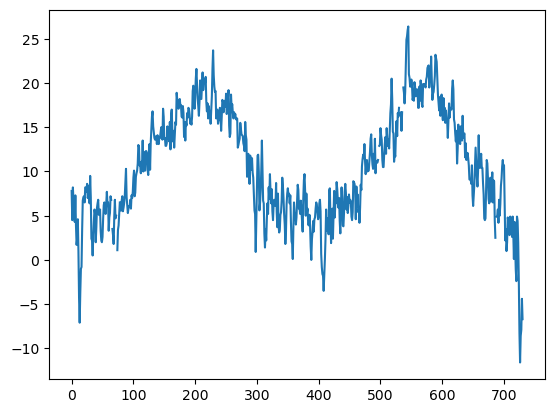

In [56]:
df['Mean Temp (°C)'].plot()

In [57]:
df['Mean Temp (°C)'].quantile(q=0.95)

np.float64(20.0)

# Vancouver Intl

## loop to get many years
have to use both Vancouver Airport stations: 
- 1108447 for 1937 - June 2013: https://climate.weather.gc.ca/climate_data/daily_data_e.html?hlyRange=1953-01-01%7C2013-06-13&dlyRange=1937-01-01%7C2013-06-12&mlyRange=1937-01-01%7C2013-06-01&climate_id=1108447&Prov=BC&urlExtension=_e.html&searchType=stnName&optLimit=yearRange&StartYear=1840&EndYear=2026&selRowPerPage=25&Line=39&searchMethod=contains&txtStationName=Vancouver&timeframe=2&Day=28&Year=1937&Month=1#
  
- 1108395 for June 2013 - present: https://climate.weather.gc.ca/climate_data/daily_data_e.html?hlyRange=2013-06-11%7C2026-06-25&dlyRange=2013-06-13%7C2026-06-25&mlyRange=%7C&climate_id=1108395&Prov=BC&urlExtension=_e.html&searchType=stnName&optLimit=yearRange&StartYear=1840&EndYear=2026&selRowPerPage=25&Line=41&searchMethod=contains&txtStationName=Vancouver&timeframe=2&time=LST&Day=25&Year=2013&Month=6#
  

In [193]:
#%%time

years1 = np.arange(1937, 2014, 1)

# start with 1960
first = years1[0] - 1

ec_en_csv = ECHistorical(station_id=1108447, year=int(first), language="english", format="csv")
await ec_en_csv.update()
df = pd.read_csv(ec_en_csv.station_data)

# add years
# up to and including 2013
for year in years1:
    ec_en_csv = ECHistorical(station_id=1108447, year=int(year), language="english", format="csv")
    await ec_en_csv.update()
    df_tmp = pd.read_csv(ec_en_csv.station_data)
    df = pd.concat([df, df_tmp], ignore_index=True)

# now add
# 2013 - 2026
years2 = np.arange(2013, 2026, 1)
for year in years2:
    ec_en_csv = ECHistorical(station_id=1108395, year=int(year), language="english", format="csv")
    await ec_en_csv.update()
    df_tmp = pd.read_csv(ec_en_csv.station_data)
    df = pd.concat([df, df_tmp], ignore_index=True)


df
    

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.20,VANCOUVER INT'L A,1108447,1936-01-01,1936,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-123.18,49.20,VANCOUVER INT'L A,1108447,1936-01-02,1936,1,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-123.18,49.20,VANCOUVER INT'L A,1108447,1936-01-03,1936,1,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-123.18,49.20,VANCOUVER INT'L A,1108447,1936-01-04,1936,1,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-123.18,49.20,VANCOUVER INT'L A,1108447,1936-01-05,1936,1,5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33233,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-27,2025,12,27,NaN,3.8,...,0.0,NaN,0.0,NaN,NaN,NaN,29.0,NaN,50.0,NaN
33234,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-28,2025,12,28,NaN,4.0,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
33235,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-29,2025,12,29,NaN,6.6,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
33236,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-30,2025,12,30,NaN,4.4,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M


In [194]:
df.describe()

,Longitude (x),Latitude (y),Climate ID,Year,Month,Day,Data Quality,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg)
count,3.323800e+04,33238.000000,3.323800e+04,33238.000000,33238.000000,33238.000000,0.0,32398.000000,32407.000000,32394.000000,32394.000000,32394.000000,32393.000000,32321.000000,32352.000000,22476.000000,11302.000000
mean,-1.231800e+02,49.198572,1.108440e+06,1980.856550,6.522895,15.729737,NaN,13.812874,6.473935,10.166676,7.963858,0.130533,2.981166,0.119554,3.097289,0.276606,19.439391
std,4.263321e-14,0.003499,1.819603e+01,26.057971,3.448764,8.800267,NaN,6.436919,5.546227,5.833848,5.624431,0.566036,6.242097,1.136825,6.328446,2.175721,8.275272
min,-1.231800e+02,49.190000,1.108395e+06,1936.000000,1.000000,1.000000,NaN,-11.100000,-17.800000,-14.500000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,-1.231800e+02,49.200000,1.108447e+06,1958.000000,4.000000,8.000000,NaN,8.900000,2.600000,5.900000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,12.000000
50%,-1.231800e+02,49.200000,1.108447e+06,1981.000000,7.000000,16.000000,NaN,13.300000,6.700000,10.000000,8.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
75%,-1.231800e+02,49.200000,1.108447e+06,2004.000000,10.000000,23.000000,NaN,19.000000,11.100000,15.000000,12.100000,0.000000,3.000000,0.000000,3.400000,0.000000,28.000000
max,-1.231800e+02,49.200000,1.108447e+06,2025.000000,12.000000,31.000000,NaN,34.400000,22.400000,28.400000,32.500000,10.400000,91.600000,41.000000,91.600000,61.000000,36.000000


<Axes: >

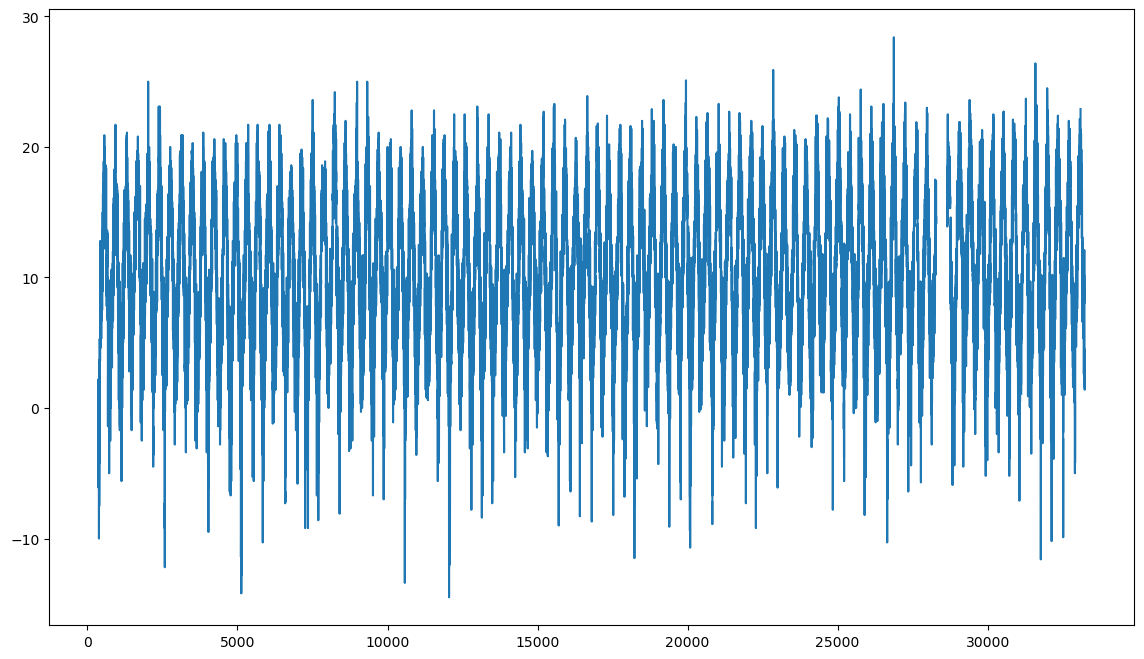

In [195]:
plt.figure(figsize=(14,8))
df['Mean Temp (°C)'].plot()

## should find those row with the missing data in June 2013 and drop them

In [196]:
df.dropna(subset = ['Mean Temp (°C)'], inplace=True)
df = df.reset_index(drop=True)
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-123.18,49.20,VANCOUVER INT'L A,1108447,1937-01-01,1937,1,1,NaN,3.9,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-123.18,49.20,VANCOUVER INT'L A,1108447,1937-01-02,1937,1,2,NaN,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-123.18,49.20,VANCOUVER INT'L A,1108447,1937-01-03,1937,1,3,NaN,6.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-123.18,49.20,VANCOUVER INT'L A,1108447,1937-01-04,1937,1,4,NaN,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-123.18,49.20,VANCOUVER INT'L A,1108447,1937-01-05,1937,1,5,NaN,-1.1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32389,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-27,2025,12,27,NaN,3.8,...,0.0,NaN,0.0,NaN,NaN,NaN,29.0,NaN,50.0,NaN
32390,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-28,2025,12,28,NaN,4.0,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
32391,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-29,2025,12,29,NaN,6.6,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M
32392,-123.18,49.19,VANCOUVER INTL A,1108395,2025-12-30,2025,12,30,NaN,4.4,...,0.0,NaN,0.0,NaN,NaN,NaN,NaN,M,NaN,M


<Axes: >

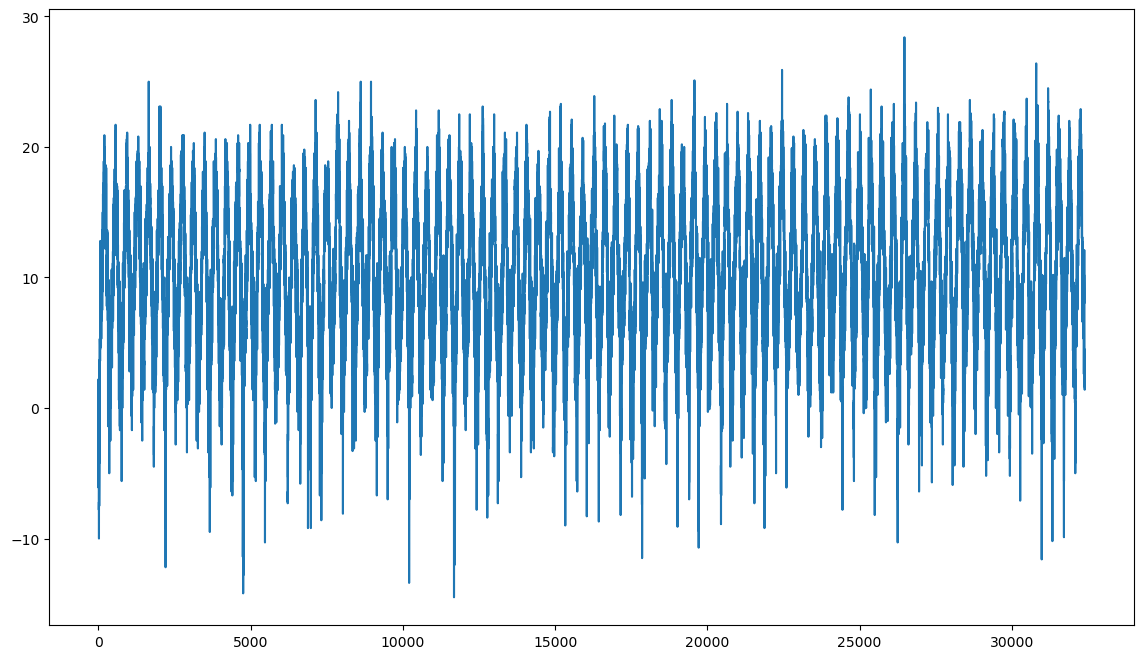

In [197]:
# replot
plt.figure(figsize=(14,8))
df['Mean Temp (°C)'].plot()

In [198]:
df.query('(Year == 2013) & (Month == 6)')

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
27872,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-01,2013,6,1,NaN,18.0,...,0.0,NaN,0.2,NaN,0.0,NaN,NaN,NaN,<31,NaN
27873,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-02,2013,6,2,NaN,18.1,...,0.0,NaN,0.0,NaN,0.0,NaN,29.0,E,44,E
27874,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-03,2013,6,3,NaN,18.6,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,<31,NaN
27875,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-04,2013,6,4,NaN,20.6,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,<31,NaN
27876,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-05,2013,6,5,NaN,20.1,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,<31,NaN
27877,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-06,2013,6,6,NaN,22.0,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,<31,NaN
27878,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-07,2013,6,7,NaN,20.0,...,0.0,NaN,0.0,T,0.0,NaN,12.0,NaN,32,NaN
27879,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-08,2013,6,8,NaN,19.2,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,<31,NaN
27880,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-09,2013,6,9,NaN,18.2,...,0.0,NaN,0.6,NaN,0.0,NaN,NaN,NaN,<31,NaN
27881,-123.18,49.20,VANCOUVER INT'L A,1108447,2013-06-10,2013,6,10,NaN,19.0,...,0.0,NaN,0.0,NaN,0.0,NaN,NaN,NaN,<31,NaN


## write out processed raw data

In [212]:
df.to_csv("./data/vancouver_intl_ECCC_1937_2025.csv")



## read data back in

In [3]:
# read data back in
df = pd.read_csv("./data/vancouver_intl_ECCC_1937_2025.csv")

/var/folders/ml/p381h5fs0x9g7g5ksj8fh6qh0000gn/T/ipykernel_78899/1604032151.py:2: DtypeWarning: Columns (0: Max Temp Flag, 1: Min Temp Flag, 2: Mean Temp Flag, 3: Heat Deg Days Flag, 4: Cool Deg Days Flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("./data/vancouver_intl_ECCC_1937_2025.csv")


In [5]:
df.query('Year == 2024')['Mean Temp (°C)']

31699    3.6
31700    5.8
31701    7.7
31702    7.0
31703    5.6
        ... 
32043    6.8
32044    8.6
32045    5.1
32046    4.3
32047    5.0
Name: Mean Temp (°C), Length: 349, dtype: float64

## Cleaned up - now compute percentiles of daily mean - annual values

In [200]:
years = np.unique(df.Year)

df_pcts = pd.DataFrame({'Year':[], 'MeanT':[], 'MinT':[], 'MaxT':[],
                        'P95':[],
                        'P90':[],
                        'P80':[],
                        'P70':[],
                        'P60':[],
                        'P50':[],
                        'P40':[],
                        'P30':[],
                        'P20':[],
                        'P10':[],
                        'P05':[]
                       })
df_pcts

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05


In [201]:
%%time
# build upa data frame of the %-ile temperatures
for year in years:
    p95 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.95)
    p90 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.90)
    p80 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.80)
    p70 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.70)
    p60 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.60)
    p50 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.50)
    p40 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.40)
    p30 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.30)
    p20 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.20)
    p10 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.10)
    p05 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.05)
    meanT = df.query('Year == @year')['Mean Temp (°C)'].mean()
    minT = df.query('Year == @year')['Mean Temp (°C)'].min()
    maxT = df.query('Year == @year')['Mean Temp (°C)'].max()


    df_tmp = pd.DataFrame({'Year':[int(year)], 'MeanT':[meanT], 'MinT':[minT], 'MaxT':[maxT],
                        'P95':[p95],
                        'P90':[p90],
                        'P80':[p80],
                        'P70':[p70],
                        'P60':[p60],
                        'P50':[p50],
                        'P40':[p40],
                        'P30':[p30],
                        'P20':[p20],
                        'P10':[p10],
                        'P05':[p05]
                       })
    
    df_pcts = pd.concat([df_pcts, df_tmp], ignore_index=True)

CPU times: user 1.54 s, sys: 20.2 ms, total: 1.56 s
Wall time: 1.56 s


In [202]:
df_pcts

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05
0,1937.0,9.077686,-10.0,20.9,17.77,16.70,15.30,13.34,11.10,9.50,8.40,6.70,4.2,-0.84,-3.85
1,1938.0,9.713850,-2.5,21.7,17.50,16.70,15.60,14.70,11.70,9.20,7.80,5.90,4.2,2.20,0.90
2,1939.0,10.143288,-5.6,21.1,17.80,16.70,14.80,13.40,11.78,10.30,8.90,7.50,5.3,3.30,2.22
3,1940.0,10.872131,-2.5,20.8,18.30,17.50,16.40,15.00,13.30,10.85,9.20,7.50,5.9,3.10,1.40
4,1941.0,10.835068,-4.4,25.0,18.40,17.26,15.60,14.20,12.30,10.60,9.20,8.10,6.4,4.02,2.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2021.0,10.494737,-11.6,26.4,20.50,19.50,17.10,14.20,11.70,10.40,8.10,6.40,4.9,3.20,1.00
85,2022.0,10.131933,-10.2,24.5,20.22,18.84,16.58,14.52,11.90,9.50,7.70,6.00,4.4,2.40,0.28
86,2023.0,11.041783,-3.9,22.4,19.83,18.70,17.10,15.60,13.36,10.80,8.20,6.80,5.5,4.00,2.89
87,2024.0,10.737822,-9.9,22.0,19.30,18.50,16.10,13.96,11.98,10.20,8.82,7.70,6.1,4.20,2.60


In [213]:
df_pcts.to_csv("./data/vancouver_intl_ECCC_1937_2025_pcts.csv")

## read pcts data back in

In [6]:
df_pcts = pd.read_csv("./data/vancouver_intl_ECCC_1937_2025_pcts.csv")

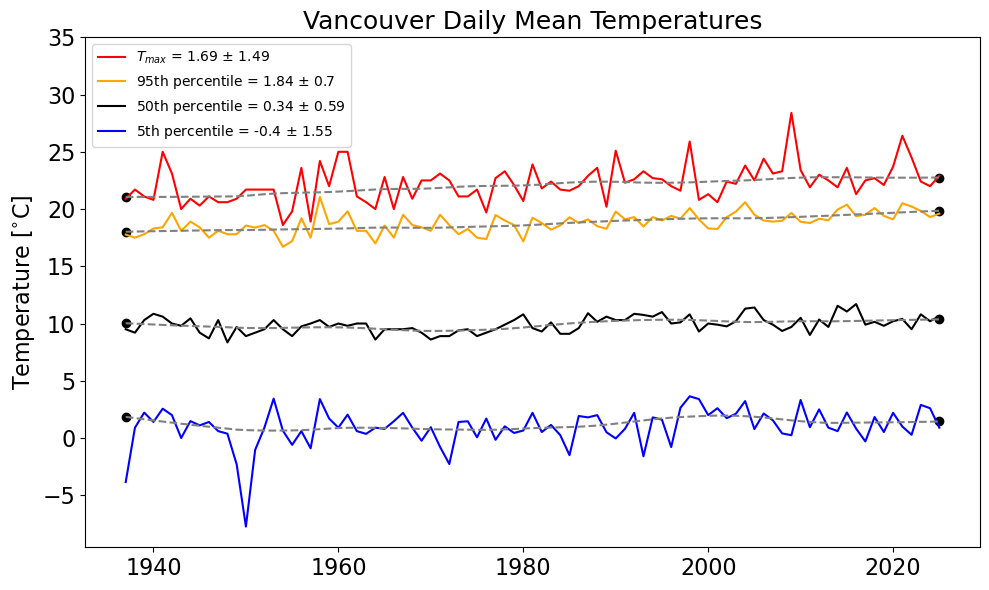

In [209]:
fig, ax = plt.subplots(figsize=(10,6))

first = df_pcts['Year'][0]
last = df_pcts['Year'].iloc[-1]

# Tmax
lowessMaxT = sm.nonparametric.lowess(df_pcts['MaxT'], df_pcts['Year'], frac=0.3)
residMaxT = lowessMaxT[:,1] - df_pcts['MaxT']
spanMaxT = np.round(lowessMaxT[-1][1] - lowessMaxT[0][1], 2)
stdMaxT = np.round(np.std(residMaxT),2)
ax.plot('Year', 'MaxT', data=df_pcts, color="red", label='$T_{max}$ = '+str(spanMaxT)+' $\\pm$ '+str(stdMaxT))
ax.plot(lowessMaxT[:, 0], lowessMaxT[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowessMaxT[0][0], lowessMaxT[0][1], c="black")
ax.scatter(lowessMaxT[-1][0], lowessMaxT[-1][1], c="black")


# P95
lowess95 = sm.nonparametric.lowess(df_pcts['P95'], df_pcts['Year'], frac=0.3)
resid95 = lowess95[:,1] - df_pcts['P95']
span95 = np.round(lowess95[-1][1] - lowess95[0][1], 2)
std95 = np.round(np.std(resid95),2)
ax.plot('Year', 'P95', data=df_pcts, color="orange", label='95th percentile = '+str(span95)+' $\\pm$ '+str(std95))
ax.plot(lowess95[:, 0], lowess95[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess95[0][0], lowess95[0][1], c="black")
ax.scatter(lowess95[-1][0], lowess95[-1][1], c="black")

# P50
lowess50 = sm.nonparametric.lowess(df_pcts['P50'], df_pcts['Year'], frac=0.3)
resid50 = lowess50[:,1] - df_pcts['P50']
span50 = np.round(lowess50[-1][1] - lowess50[0][1], 2)
std50 = np.round(np.std(resid50),2)
ax.plot('Year', 'P50', data=df_pcts, color="black", label='50th percentile = '+str(span50)+' $\\pm$ '+str(std50))
ax.plot(lowess50[:, 0], lowess50[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess50[0][0], lowess50[0][1], c="black")
ax.scatter(lowess50[-1][0], lowess50[-1][1], c="black")


#P05
lowess05 = sm.nonparametric.lowess(df_pcts['P05'], df_pcts['Year'], frac=0.3)
resid05 = lowess05[:,1] - df_pcts['P05']
span05 = np.round(lowess05[-1][1] - lowess05[0][1], 2)
std05 = np.round(np.std(resid05),2)
ax.plot('Year', 'P05', data=df_pcts, color="blue", label='5th percentile = '+str(span05)+' $\\pm$ '+str(std05))
ax.plot(lowess05[:, 0], lowess05[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess05[0][0], lowess05[0][1], c="black")
ax.scatter(lowess05[-1][0], lowess05[-1][1], c="black")

# other plot stuff
ax.legend(loc="upper left", fontsize=10)
ax.set_title("Vancouver Daily Mean Temperatures", fontsize=18)
ax.set_ylabel('Temperature [$^{\\circ}$C]', fontsize=16)
ax.set_xlabel("")
plt.xticks(fontsize=16)
plt.yticks(np.arange(-5,40,5), fontsize=16)
plt.tight_layout()
plt.show()


# Fit the LOWESS regression model
# lowess = sm.nonparametric.lowess(y, x, frac=0.3)

# # Plot the results
# plt.scatter(x, y, label='data')
# plt.plot(lowess[:, 0], lowess[:, 1], label='LOWESS')

np.float64(2025.0)

## Same but for JJA only

In [204]:
years = np.unique(df.Year)

df_pcts_summ = pd.DataFrame({'Year':[], 'MeanT':[], 'MinT':[], 'MaxT':[],
                        'P95':[],
                        'P90':[],
                        'P80':[],
                        'P70':[],
                        'P60':[],
                        'P50':[],
                        'P40':[],
                        'P30':[],
                        'P20':[],
                        'P10':[],
                        'P05':[]
                       })
df_pcts_summ

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05


32192    6
32193    6
32194    6
32195    6
32196    6
        ..
32272    8
32273    8
32274    8
32275    8
32276    8
Name: Month, Length: 85, dtype: int64

In [207]:
%%time
# build upa data frame of the %-ile temperatures
for year in years:
    p95 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.95)
    p90 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.90)
    p80 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.80)
    p70 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.70)
    p60 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.60)
    p50 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.50)
    p40 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.40)
    p30 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.30)
    p20 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.20)
    p10 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.10)
    p05 = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.05)
    meanT = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].mean()
    minT = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].min()
    maxT = df.query('(Year == @year) & (Month in [6,7,8])')['Mean Temp (°C)'].max()


    df_tmp = pd.DataFrame({'Year':[int(year)], 'MeanT':[meanT], 'MinT':[minT], 'MaxT':[maxT],
                        'P95':[p95],
                        'P90':[p90],
                        'P80':[p80],
                        'P70':[p70],
                        'P60':[p60],
                        'P50':[p50],
                        'P40':[p40],
                        'P30':[p30],
                        'P20':[p20],
                        'P10':[p10],
                        'P05':[p05]
                       })
    
    df_pcts_summ = pd.concat([df_pcts_summ, df_tmp], ignore_index=True)

CPU times: user 1.77 s, sys: 28.2 ms, total: 1.8 s
Wall time: 1.8 s


In [208]:
df_pcts_summ

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05
0,1937.0,15.993478,12.2,20.9,18.900,18.39,17.46,16.91,16.40,15.90,15.42,15.00,14.50,13.63,13.100
1,1938.0,16.254348,11.7,21.7,19.725,18.10,17.50,16.70,16.40,16.20,15.90,15.60,15.00,14.25,13.100
2,1939.0,15.911957,10.8,21.1,20.300,19.12,17.80,17.00,16.40,15.90,15.60,14.73,13.96,12.80,12.000
3,1940.0,16.913043,13.1,20.8,19.035,18.58,18.10,17.80,17.50,17.20,16.70,16.20,15.82,14.70,14.455
4,1941.0,17.133696,13.1,25.0,21.835,19.17,18.40,17.71,17.26,17.00,16.52,15.90,15.60,15.00,14.310
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
84,2021.0,18.705556,11.1,26.4,23.110,21.91,20.52,19.83,19.50,18.75,18.16,17.27,16.60,15.68,14.345
85,2022.0,18.063636,13.3,24.5,22.865,21.25,20.26,19.48,18.52,18.10,17.38,16.60,15.64,14.60,13.940
86,2023.0,17.885870,12.1,22.4,20.690,20.30,19.58,19.20,18.50,18.20,17.50,16.90,16.22,15.40,13.865
87,2024.0,17.340000,12.0,22.0,21.080,20.46,19.34,18.78,18.44,17.50,16.80,16.16,15.10,13.74,13.120


In [214]:
df_pcts_summ.to_csv("./data/vancouver_intl_ECCC_1937_2025_pcts_JJA.csv")

## read JJA pcts back in and plot

In [7]:
df_pcts_summ = pd.read_csv("./data/vancouver_intl_ECCC_1937_2025_pcts_JJA.csv")

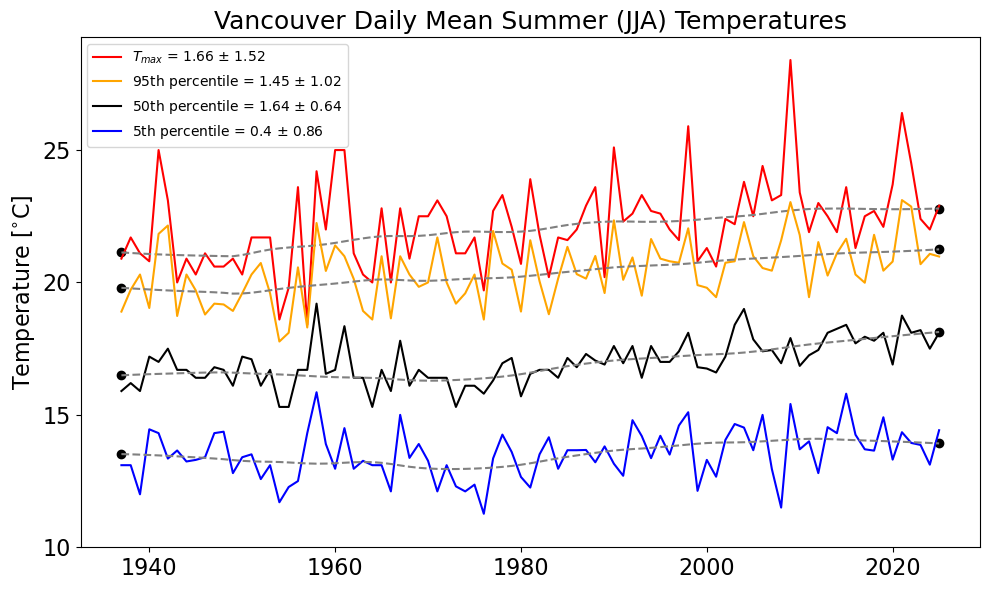

In [211]:
fig, ax = plt.subplots(figsize=(10,6))

first = df_pcts_summ['Year'][0]
last = df_pcts_summ['Year'].iloc[-1]

# Tmax
lowessMaxT = sm.nonparametric.lowess(df_pcts_summ['MaxT'], df_pcts_summ['Year'], frac=0.3)
residMaxT = lowessMaxT[:,1] - df_pcts_summ['MaxT']
spanMaxT = np.round(lowessMaxT[-1][1] - lowessMaxT[0][1], 2)
stdMaxT = np.round(np.std(residMaxT),2)
ax.plot('Year', 'MaxT', data=df_pcts_summ, color="red", label='$T_{max}$ = '+str(spanMaxT)+' $\\pm$ '+str(stdMaxT))
ax.plot(lowessMaxT[:, 0], lowessMaxT[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowessMaxT[0][0], lowessMaxT[0][1], c="black")
ax.scatter(lowessMaxT[-1][0], lowessMaxT[-1][1], c="black")


# P95
lowess95 = sm.nonparametric.lowess(df_pcts_summ['P95'], df_pcts_summ['Year'], frac=0.3)
resid95 = lowess95[:,1] - df_pcts_summ['P95']
span95 = np.round(lowess95[-1][1] - lowess95[0][1], 2)
std95 = np.round(np.std(resid95),2)
ax.plot('Year', 'P95', data=df_pcts_summ, color="orange", label='95th percentile = '+str(span95)+' $\\pm$ '+str(std95))
ax.plot(lowess95[:, 0], lowess95[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess95[0][0], lowess95[0][1], c="black")
ax.scatter(lowess95[-1][0], lowess95[-1][1], c="black")

# P50
lowess50 = sm.nonparametric.lowess(df_pcts_summ['P50'], df_pcts_summ['Year'], frac=0.3)
resid50 = lowess50[:,1] - df_pcts_summ['P50']
span50 = np.round(lowess50[-1][1] - lowess50[0][1], 2)
std50 = np.round(np.std(resid50),2)
ax.plot('Year', 'P50', data=df_pcts_summ, color="black", label='50th percentile = '+str(span50)+' $\\pm$ '+str(std50))
ax.plot(lowess50[:, 0], lowess50[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess50[0][0], lowess50[0][1], c="black")
ax.scatter(lowess50[-1][0], lowess50[-1][1], c="black")


#P05
lowess05 = sm.nonparametric.lowess(df_pcts_summ['P05'], df_pcts_summ['Year'], frac=0.3)
resid05 = lowess05[:,1] - df_pcts_summ['P05']
span05 = np.round(lowess05[-1][1] - lowess05[0][1], 2)
std05 = np.round(np.std(resid05),2)
ax.plot('Year', 'P05', data=df_pcts_summ, color="blue", label='5th percentile = '+str(span05)+' $\\pm$ '+str(std05))
ax.plot(lowess05[:, 0], lowess05[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess05[0][0], lowess05[0][1], c="black")
ax.scatter(lowess05[-1][0], lowess05[-1][1], c="black")

# other plot stuff
ax.legend(loc="upper left", fontsize=10)
ax.set_title("Vancouver Daily Mean Summer (JJA) Temperatures", fontsize=18)
ax.set_ylabel('Temperature [$^{\\circ}$C]', fontsize=16)
ax.set_xlabel("")
plt.xticks(fontsize=16)
plt.yticks(np.arange(10,30,5), fontsize=16)
plt.tight_layout()
plt.show()


# Fit the LOWESS regression model
# lowess = sm.nonparametric.lowess(y, x, frac=0.3)

# # Plot the results
# plt.scatter(x, y, label='data')
# plt.plot(lowess[:, 0], lowess[:, 1], label='LOWESS')

# Toronto Intl

## loop to get many years
have to use both Toronto Airport stations: 
- 6158733 for 1937 - June 2013: https://climate.weather.gc.ca/climate_data/daily_data_e.html?hlyRange=1953-01-01%7C2013-06-13&dlyRange=1937-11-01%7C2013-06-13&mlyRange=1937-01-01%7C2013-06-01&climate_id=6158733&Prov=ON&urlExtension=_e.html&searchType=stnName&optLimit=yearRange&StartYear=1840&EndYear=2026&selRowPerPage=25&Line=61&searchMethod=contains&Month=6&Day=1&txtStationName=Toronto&timeframe=2&Year=2013
  
- 6158731 for June 2013 - present: https://climate.weather.gc.ca/climate_data/daily_data_e.html?hlyRange=2013-06-11%7C2026-07-01&dlyRange=2013-06-13%7C2026-07-01&mlyRange=%7C&climate_id=6158731&Prov=ON&urlExtension=_e.html&searchType=stnName&optLimit=yearRange&StartYear=1840&EndYear=2026&selRowPerPage=25&Line=51&searchMethod=contains&txtStationName=Toronto&timeframe=2&Day=1&Year=2013&Month=6#
  

In [216]:
#%%time

years1 = np.arange(1937, 2014, 1)

# start with 1960
first = years1[0] - 1

ec_en_csv = ECHistorical(station_id=6158733, year=int(first), language="english", format="csv")
await ec_en_csv.update()
df = pd.read_csv(ec_en_csv.station_data)

# add years
# up to and including 2013
for year in years1:
    ec_en_csv = ECHistorical(station_id=1108447, year=int(year), language="english", format="csv")
    await ec_en_csv.update()
    df_tmp = pd.read_csv(ec_en_csv.station_data)
    df = pd.concat([df, df_tmp], ignore_index=True)

# now add
# 2013 - 2026
years2 = np.arange(2013, 2026, 1)
for year in years2:
    ec_en_csv = ECHistorical(station_id=6158731, year=int(year), language="english", format="csv")
    await ec_en_csv.update()
    df_tmp = pd.read_csv(ec_en_csv.station_data)
    df = pd.concat([df, df_tmp], ignore_index=True)


df
    

,Longitude (x),Latitude (y),Station Name,Climate ID,Date/Time,Year,Month,Day,Data Quality,Max Temp (°C),...,Total Snow (cm),Total Snow Flag,Total Precip (mm),Total Precip Flag,Snow on Grnd (cm),Snow on Grnd Flag,Dir of Max Gust (10s deg),Dir of Max Gust Flag,Spd of Max Gust (km/h),Spd of Max Gust Flag
0,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1936-01-01,1936,1,1,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1936-01-02,1936,1,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1936-01-03,1936,1,3,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1936-01-04,1936,1,4,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-79.63,43.68,TORONTO LESTER B. PEARSON INT'L A,6158733,1936-01-05,1936,1,5,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33233,-79.63,43.68,TORONTO INTL A,6158731,2025-12-27,2025,12,27,NaN,-2.9,...,0.0,T,0.0,T,10.0,NaN,NaN,M,NaN,M
33234,-79.63,43.68,TORONTO INTL A,6158731,2025-12-28,2025,12,28,NaN,2.4,...,0.0,NaN,41.2,NaN,8.0,NaN,25.0,NaN,45.0,NaN
33235,-79.63,43.68,TORONTO INTL A,6158731,2025-12-29,2025,12,29,NaN,5.2,...,2.0,NaN,2.4,NaN,2.0,NaN,25.0,NaN,78.0,NaN
33236,-79.63,43.68,TORONTO INTL A,6158731,2025-12-30,2025,12,30,NaN,-3.9,...,0.0,T,0.0,T,2.0,NaN,28.0,NaN,68.0,NaN


In [217]:
df.describe()

,Longitude (x),Latitude (y),Climate ID,Year,Month,Day,Data Quality,Max Temp (°C),Min Temp (°C),Mean Temp (°C),Heat Deg Days (°C),Cool Deg Days (°C),Total Rain (mm),Total Snow (cm),Total Precip (mm),Snow on Grnd (cm),Dir of Max Gust (10s deg)
count,33238.000000,33238.000000,3.323800e+04,33238.000000,33238.000000,33238.000000,0.0,32445.000000,32446.000000,32440.000000,32440.000000,32440.000000,32406.000000,32326.000000,32364.000000,22421.000000,12146.000000
mean,-116.479395,48.350693,1.885484e+06,1980.856550,6.522895,15.729737,NaN,13.767613,6.141352,9.976816,8.285000,0.261816,2.827263,0.152036,2.973001,0.506356,20.744607
std,15.713709,1.991726,1.822243e+06,26.057971,3.448764,8.800267,NaN,7.317430,6.385315,6.700069,6.279939,1.055872,6.195740,1.227920,6.294369,2.858157,8.793808
min,-123.180000,43.680000,1.108447e+06,1936.000000,1.000000,1.000000,NaN,-19.100000,-26.300000,-22.300000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-123.180000,49.200000,1.108447e+06,1958.000000,4.000000,8.000000,NaN,8.400000,2.000000,5.500000,2.700000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000
50%,-123.180000,49.200000,1.108447e+06,1981.000000,7.000000,16.000000,NaN,13.300000,6.300000,9.800000,8.200000,0.000000,0.000000,0.000000,0.000000,0.000000,23.000000
75%,-123.180000,49.200000,1.108447e+06,2004.000000,10.000000,23.000000,NaN,19.400000,11.100000,15.300000,12.500000,0.000000,2.800000,0.000000,3.000000,0.000000,29.000000
max,-79.630000,49.200000,6.158733e+06,2025.000000,12.000000,31.000000,NaN,36.000000,25.000000,30.500000,40.300000,12.500000,128.300000,41.000000,128.300000,61.000000,36.000000


<Axes: >

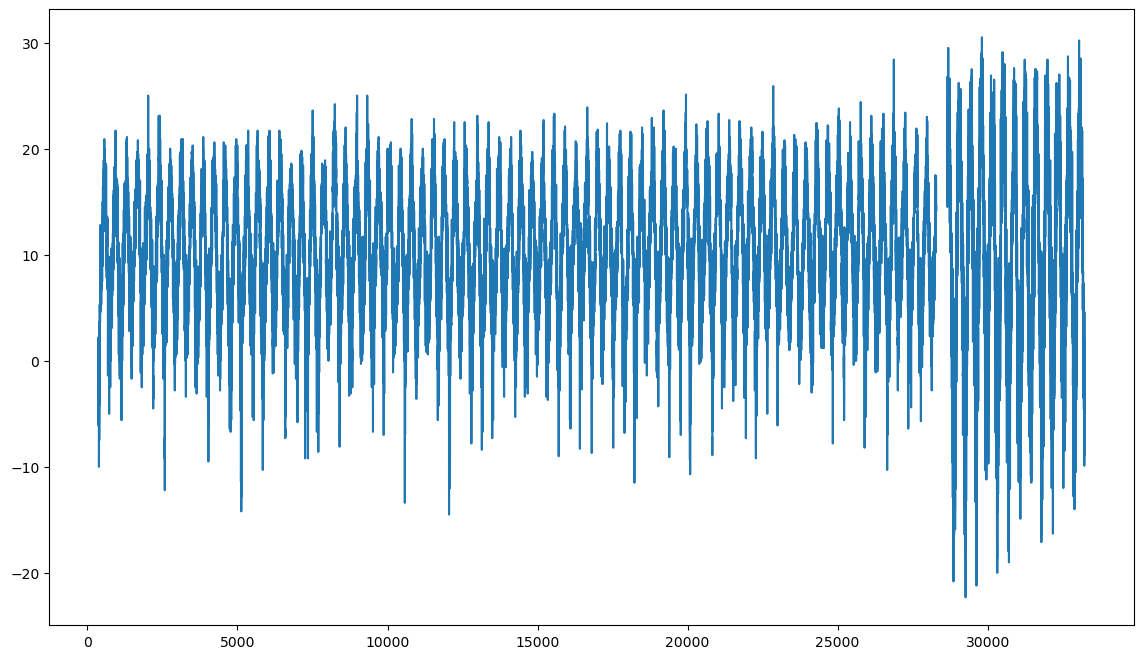

In [218]:
plt.figure(figsize=(14,8))
df['Mean Temp (°C)'].plot()

### wow the newer station in 2013 shows a lot wider range of temps! I don't see this when I use the GHCND data processing in the ER

## Will try using the data from GHCND to see if the same issue exists?

https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:CA006158733/detail 
and then https://www.ncei.noaa.gov/cdo-web/datasets/GHCND/stations/GHCND:CA006158731/detail¶

In [228]:
df1 = pd.read_csv("./data/toronto-CA006158733-1936-2013-GHCND.csv")
df2 = pd.read_csv("./data/toronto-CA006158731-2013-2025-GHCND.csv")
df = pd.concat([df1, df2], axis=0, ignore_index=True)
#df.reset_index()
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-01,NaN,15.0,-3.9
1,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-02,NaN,18.3,0.6
2,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-03,NaN,14.4,-2.2
3,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-04,NaN,9.4,0.6
4,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-05,NaN,7.2,0.6
...,...,...,...,...,...,...,...,...,...
31390,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-24,5.1,9.6,0.5
31391,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-25,3.2,8.4,-2.0
31392,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-26,6.1,12.7,-0.6
31393,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-27,10.6,14.3,6.9


In [229]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31395 entries, 0 to 31394
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    31395 non-null  str    
 1   NAME       31395 non-null  str    
 2   LATITUDE   31395 non-null  float64
 3   LONGITUDE  31395 non-null  float64
 4   ELEVATION  31395 non-null  float64
 5   DATE       31395 non-null  str    
 6   TAVG       3288 non-null   float64
 7   TMAX       31370 non-null  float64
 8   TMIN       31363 non-null  float64
dtypes: float64(6), str(3)
memory usage: 3.8 MB


In [230]:
df['TAVG'] = df['TAVG'].fillna((df['TMAX'] + df['TMIN'])/2.0)
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN
0,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-01,5.55,15.0,-3.9
1,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-02,9.45,18.3,0.6
2,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-03,6.10,14.4,-2.2
3,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-04,5.00,9.4,0.6
4,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-05,3.90,7.2,0.6
...,...,...,...,...,...,...,...,...,...
31390,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-24,5.10,9.6,0.5
31391,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-25,3.20,8.4,-2.0
31392,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-26,6.10,12.7,-0.6
31393,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-27,10.60,14.3,6.9


In [233]:
# linear interpolation to fill the last few
df['TAVG'] = df['TAVG'].interpolate(method='linear')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 31395 entries, 0 to 31394
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   STATION    31395 non-null  str    
 1   NAME       31395 non-null  str    
 2   LATITUDE   31395 non-null  float64
 3   LONGITUDE  31395 non-null  float64
 4   ELEVATION  31395 non-null  float64
 5   DATE       31395 non-null  str    
 6   TAVG       31395 non-null  float64
 7   TMAX       31370 non-null  float64
 8   TMIN       31363 non-null  float64
dtypes: float64(6), str(3)
memory usage: 3.8 MB


In [235]:
# fix up columns to be compatible with prior processing of ECCC data
df['DATE'] = pd.to_datetime(df['DATE'])
df['Year'] = df.DATE.dt.year
df['Mean Temp (°C)'] = df['TAVG']

In [236]:
df

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN,Year,Mean Temp (°C)
0,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-01,5.55,15.0,-3.9,1937,5.55
1,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-02,9.45,18.3,0.6,1937,9.45
2,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-03,6.10,14.4,-2.2,1937,6.10
3,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-04,5.00,9.4,0.6,1937,5.00
4,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,1937-11-05,3.90,7.2,0.6,1937,3.90
...,...,...,...,...,...,...,...,...,...,...,...
31390,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-24,5.10,9.6,0.5,2024,5.10
31391,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-25,3.20,8.4,-2.0,2024,3.20
31392,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-26,6.10,12.7,-0.6,2024,6.10
31393,CA006158731,"TORONTO INTERNATIONAL A, ON CA",43.6767,-79.6306,173.4,2024-04-27,10.60,14.3,6.9,2024,10.60


## this dataset does not have missing data in June 2013

In [239]:
# df.dropna(subset = ['Mean Temp (°C)'], inplace=True)
# df = df.reset_index(drop=True)
# df

<Axes: >

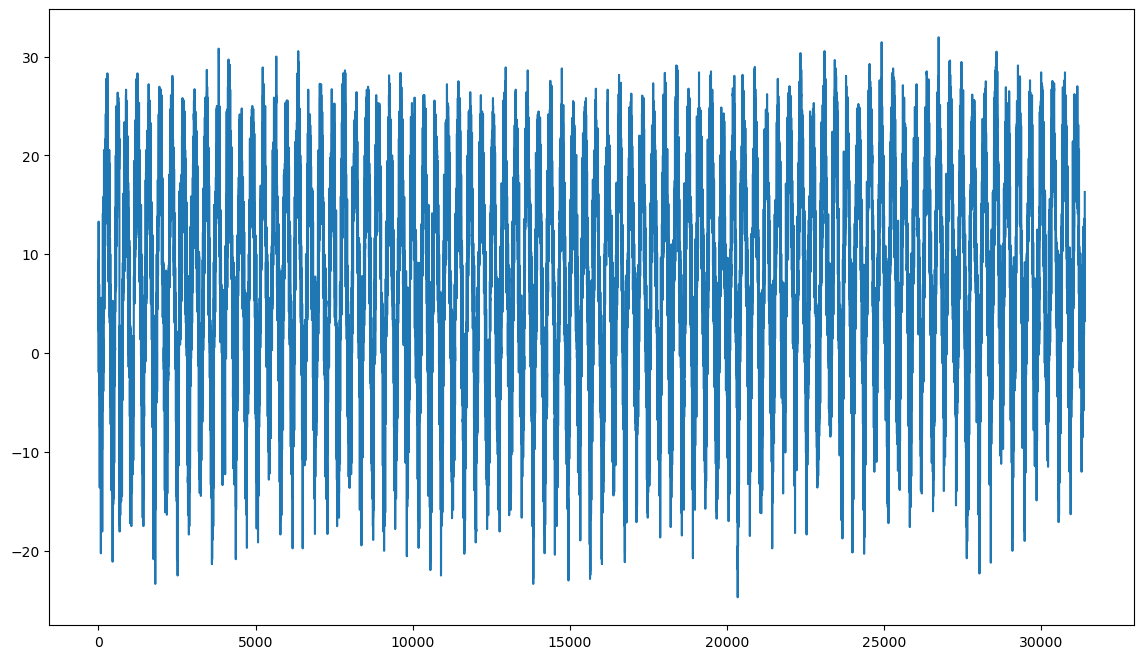

In [238]:
# replot
plt.figure(figsize=(14,8))
df['Mean Temp (°C)'].plot()

In [242]:
df.query('(Year == 2013) & (DATE.dt.month == 6)')

,STATION,NAME,LATITUDE,LONGITUDE,ELEVATION,DATE,TAVG,TMAX,TMIN,Year,Mean Temp (°C)
27424,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-01,22.80,27.1,18.5,2013,22.80
27425,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-02,16.25,23.7,8.8,2013,16.25
27426,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-03,11.55,16.3,6.8,2013,11.55
27427,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-04,14.00,20.4,7.6,2013,14.00
27428,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-05,15.25,18.7,11.8,2013,15.25
27429,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-06,13.80,15.6,12.0,2013,13.80
27430,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-07,14.10,16.2,12.0,2013,14.10
27431,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-08,16.50,20.4,12.6,2013,16.50
27432,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-09,16.75,22.6,10.9,2013,16.75
27433,CA006158733,"TORONTO LESTER B. PEARSON INT, ON CA",43.6833,-79.6333,173.0,2013-06-10,16.45,17.4,15.5,2013,16.45


In [243]:
df.to_csv("./data/toronto_intl_GHCND_1937_2025.csv")

## read processed raw data back in

In [8]:
df = pd.read_csv("./data/toronto_intl_GHCND_1937_2025.csv")

## Cleaned up - now compute percentiles of daily mean - annual values

In [244]:
years = np.unique(df.Year)

df_pcts = pd.DataFrame({'Year':[], 'MeanT':[], 'MinT':[], 'MaxT':[],
                        'P95':[],
                        'P90':[],
                        'P80':[],
                        'P70':[],
                        'P60':[],
                        'P50':[],
                        'P40':[],
                        'P30':[],
                        'P20':[],
                        'P10':[],
                        'P05':[]
                       })
df_pcts

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05


In [245]:
%%time
# build upa data frame of the %-ile temperatures
for year in years:
    p95 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.95)
    p90 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.90)
    p80 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.80)
    p70 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.70)
    p60 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.60)
    p50 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.50)
    p40 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.40)
    p30 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.30)
    p20 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.20)
    p10 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.10)
    p05 = df.query('Year == @year')['Mean Temp (°C)'].quantile(q=0.05)
    meanT = df.query('Year == @year')['Mean Temp (°C)'].mean()
    minT = df.query('Year == @year')['Mean Temp (°C)'].min()
    maxT = df.query('Year == @year')['Mean Temp (°C)'].max()


    df_tmp = pd.DataFrame({'Year':[int(year)], 'MeanT':[meanT], 'MinT':[minT], 'MaxT':[maxT],
                        'P95':[p95],
                        'P90':[p90],
                        'P80':[p80],
                        'P70':[p70],
                        'P60':[p60],
                        'P50':[p50],
                        'P40':[p40],
                        'P30':[p30],
                        'P20':[p20],
                        'P10':[p10],
                        'P05':[p05]
                       })
    
    df_pcts = pd.concat([df_pcts, df_tmp], ignore_index=True)

CPU times: user 861 ms, sys: 17.8 ms, total: 879 ms
Wall time: 877 ms


In [246]:
df_pcts

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05
0,1937.0,-0.735656,-13.60,13.30,7.7500,6.10,3.65,1.40,0.00,-1.525,-2.50,-3.325,-4.45,-7.500,-8.9000
1,1938.0,8.122740,-20.25,28.30,23.6000,22.23,18.31,15.25,12.60,8.600,5.58,1.360,-2.75,-5.830,-9.5500
2,1939.0,7.942181,-21.10,26.35,23.5750,22.50,20.28,18.60,15.55,8.900,2.10,-1.100,-4.15,-8.640,-11.0750
3,1940.0,6.072131,-18.05,26.65,22.6875,20.95,16.95,14.15,10.55,6.275,2.20,-0.800,-5.00,-9.025,-12.1375
4,1941.0,8.119452,-17.50,28.30,24.0400,22.20,18.65,16.31,12.50,8.900,5.15,0.660,-2.85,-7.100,-9.3400
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2020.0,9.763934,-14.90,28.40,25.1000,23.85,20.80,16.20,12.20,8.350,5.30,2.600,0.50,-2.750,-5.0750
84,2021.0,10.150274,-11.50,27.50,25.6600,23.40,20.40,18.00,14.74,9.800,6.62,3.020,0.20,-3.600,-7.0000
85,2022.0,9.149313,-17.10,28.40,24.6400,22.60,20.80,17.92,12.90,10.000,6.12,1.500,-1.10,-6.270,-10.1125
86,2023.0,10.126027,-16.30,27.00,23.1800,22.00,19.70,17.80,14.64,9.100,6.00,3.100,1.20,-1.360,-3.4600


In [249]:
df_pcts.to_csv("./data/toronto_intl_GHCND_1937_2024_pcts.csv")

## read pcts data back in and plot

In [9]:
df_pcts = pd.read_csv("./data/toronto_intl_GHCND_1937_2024_pcts.csv")

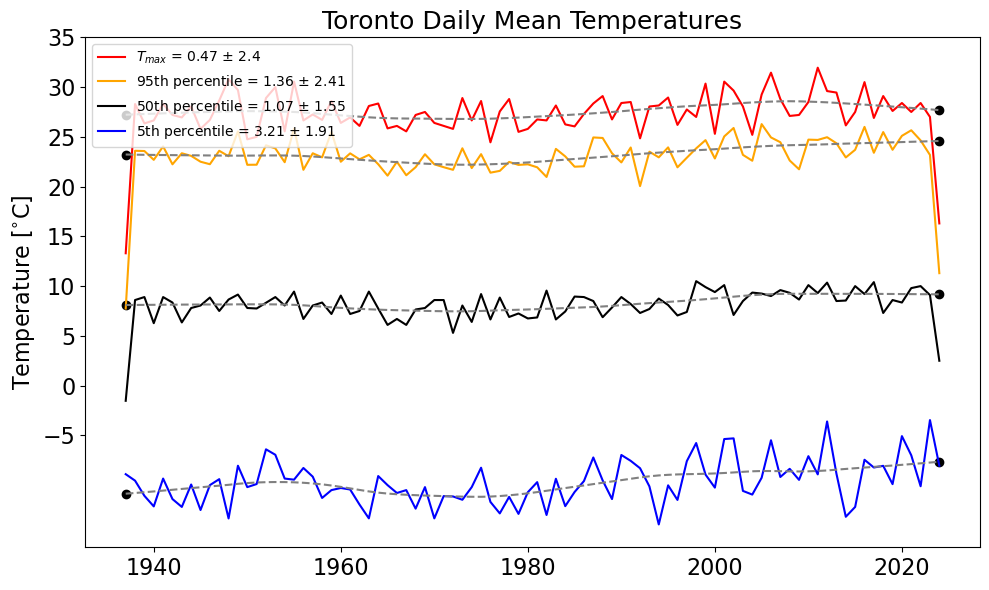

In [248]:
fig, ax = plt.subplots(figsize=(10,6))

first = df_pcts['Year'][0]
last = df_pcts['Year'].iloc[-1]

# Tmax
lowessMaxT = sm.nonparametric.lowess(df_pcts['MaxT'], df_pcts['Year'], frac=0.3)
residMaxT = lowessMaxT[:,1] - df_pcts['MaxT']
spanMaxT = np.round(lowessMaxT[-1][1] - lowessMaxT[0][1], 2)
stdMaxT = np.round(np.std(residMaxT),2)
ax.plot('Year', 'MaxT', data=df_pcts, color="red", label='$T_{max}$ = '+str(spanMaxT)+' $\\pm$ '+str(stdMaxT))
ax.plot(lowessMaxT[:, 0], lowessMaxT[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowessMaxT[0][0], lowessMaxT[0][1], c="black")
ax.scatter(lowessMaxT[-1][0], lowessMaxT[-1][1], c="black")


# P95
lowess95 = sm.nonparametric.lowess(df_pcts['P95'], df_pcts['Year'], frac=0.3)
resid95 = lowess95[:,1] - df_pcts['P95']
span95 = np.round(lowess95[-1][1] - lowess95[0][1], 2)
std95 = np.round(np.std(resid95),2)
ax.plot('Year', 'P95', data=df_pcts, color="orange", label='95th percentile = '+str(span95)+' $\\pm$ '+str(std95))
ax.plot(lowess95[:, 0], lowess95[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess95[0][0], lowess95[0][1], c="black")
ax.scatter(lowess95[-1][0], lowess95[-1][1], c="black")

# P50
lowess50 = sm.nonparametric.lowess(df_pcts['P50'], df_pcts['Year'], frac=0.3)
resid50 = lowess50[:,1] - df_pcts['P50']
span50 = np.round(lowess50[-1][1] - lowess50[0][1], 2)
std50 = np.round(np.std(resid50),2)
ax.plot('Year', 'P50', data=df_pcts, color="black", label='50th percentile = '+str(span50)+' $\\pm$ '+str(std50))
ax.plot(lowess50[:, 0], lowess50[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess50[0][0], lowess50[0][1], c="black")
ax.scatter(lowess50[-1][0], lowess50[-1][1], c="black")


#P05
lowess05 = sm.nonparametric.lowess(df_pcts['P05'], df_pcts['Year'], frac=0.3)
resid05 = lowess05[:,1] - df_pcts['P05']
span05 = np.round(lowess05[-1][1] - lowess05[0][1], 2)
std05 = np.round(np.std(resid05),2)
ax.plot('Year', 'P05', data=df_pcts, color="blue", label='5th percentile = '+str(span05)+' $\\pm$ '+str(std05))
ax.plot(lowess05[:, 0], lowess05[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess05[0][0], lowess05[0][1], c="black")
ax.scatter(lowess05[-1][0], lowess05[-1][1], c="black")

# other plot stuff
ax.legend(loc="upper left", fontsize=10)
ax.set_title("Toronto Daily Mean Temperatures", fontsize=18)
ax.set_ylabel('Temperature [$^{\\circ}$C]', fontsize=16)
ax.set_xlabel("")
plt.xticks(fontsize=16)
plt.yticks(np.arange(-5,40,5), fontsize=16)
plt.tight_layout()
plt.show()


# Fit the LOWESS regression model
# lowess = sm.nonparametric.lowess(y, x, frac=0.3)

# # Plot the results
# plt.scatter(x, y, label='data')
# plt.plot(lowess[:, 0], lowess[:, 1], label='LOWESS')

### clearly the data ending in april 2024 messes with the end

## Same but for JJA only

In [250]:
years = np.unique(df.Year)

df_pcts_summ = pd.DataFrame({'Year':[], 'MeanT':[], 'MinT':[], 'MaxT':[],
                        'P95':[],
                        'P90':[],
                        'P80':[],
                        'P70':[],
                        'P60':[],
                        'P50':[],
                        'P40':[],
                        'P30':[],
                        'P20':[],
                        'P10':[],
                        'P05':[]
                       })
df_pcts_summ

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05


In [251]:
%%time
# build upa data frame of the %-ile temperatures
for year in years:
    p95 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.95)
    p90 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.90)
    p80 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.80)
    p70 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.70)
    p60 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.60)
    p50 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.50)
    p40 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.40)
    p30 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.30)
    p20 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.20)
    p10 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.10)
    p05 = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].quantile(q=0.05)
    meanT = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].mean()
    minT = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].min()
    maxT = df.query('(Year == @year) & (DATE.dt.month in [6,7,8])')['Mean Temp (°C)'].max()


    df_tmp = pd.DataFrame({'Year':[int(year)], 'MeanT':[meanT], 'MinT':[minT], 'MaxT':[maxT],
                        'P95':[p95],
                        'P90':[p90],
                        'P80':[p80],
                        'P70':[p70],
                        'P60':[p60],
                        'P50':[p50],
                        'P40':[p40],
                        'P30':[p30],
                        'P20':[p20],
                        'P10':[p10],
                        'P05':[p05]
                       })
    
    df_pcts_summ = pd.concat([df_pcts_summ, df_tmp], ignore_index=True)

CPU times: user 1.61 s, sys: 55.8 ms, total: 1.66 s
Wall time: 1.69 s


In [252]:
df_pcts_summ

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05
0,1937.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1938.0,20.602174,10.85,28.30,26.5350,24.450,23.60,22.75,22.23,21.375,19.72,18.600,17.00,15.355,13.9000
2,1939.0,20.185326,10.85,26.35,24.9700,23.600,23.00,21.95,21.10,20.300,19.55,18.710,18.11,16.100,15.0525
3,1940.0,18.827174,8.30,26.65,25.2725,24.700,22.70,21.65,20.33,19.050,17.90,15.565,14.71,13.670,11.9500
4,1941.0,20.088587,12.20,28.30,26.8975,25.225,23.05,22.50,21.10,19.875,18.62,17.875,16.65,15.580,13.9000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
83,2020.0,22.516304,12.90,28.40,27.3450,26.600,25.10,24.37,23.70,23.050,22.38,21.200,19.92,17.790,15.9100
84,2021.0,22.288043,14.80,27.50,27.0450,26.590,25.66,24.17,23.40,22.025,21.30,20.500,19.82,17.850,16.8100
85,2022.0,21.605435,14.20,28.40,26.4900,26.100,24.20,23.07,22.10,21.400,21.00,20.300,19.16,17.310,16.6550
86,2023.0,20.555435,15.30,26.20,25.2800,23.700,22.50,22.00,21.50,20.450,19.64,19.230,18.60,16.420,15.9550


In [255]:
# drop last row of NaNs
df_pcts_summ.dropna(subset = ['MeanT'], inplace=True)
df_pcts_summ = df_pcts_summ.reset_index(drop=True)
df_pcts_summ

,Year,MeanT,MinT,MaxT,P95,P90,P80,P70,P60,P50,P40,P30,P20,P10,P05
0,1938.0,20.602174,10.85,28.30,26.5350,24.450,23.60,22.750,22.23,21.375,19.72,18.600,17.00,15.355,13.9000
1,1939.0,20.185326,10.85,26.35,24.9700,23.600,23.00,21.950,21.10,20.300,19.55,18.710,18.11,16.100,15.0525
2,1940.0,18.827174,8.30,26.65,25.2725,24.700,22.70,21.650,20.33,19.050,17.90,15.565,14.71,13.670,11.9500
3,1941.0,20.088587,12.20,28.30,26.8975,25.225,23.05,22.500,21.10,19.875,18.62,17.875,16.65,15.580,13.9000
4,1942.0,19.240761,11.95,27.20,24.5075,23.520,21.69,20.835,20.28,19.450,18.60,17.875,16.36,14.480,13.8775
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
81,2019.0,20.990217,11.60,27.60,26.2350,24.880,23.66,22.900,22.02,21.100,20.30,19.900,18.80,16.530,15.0950
82,2020.0,22.516304,12.90,28.40,27.3450,26.600,25.10,24.370,23.70,23.050,22.38,21.200,19.92,17.790,15.9100
83,2021.0,22.288043,14.80,27.50,27.0450,26.590,25.66,24.170,23.40,22.025,21.30,20.500,19.82,17.850,16.8100
84,2022.0,21.605435,14.20,28.40,26.4900,26.100,24.20,23.070,22.10,21.400,21.00,20.300,19.16,17.310,16.6550


In [256]:
df_pcts_summ.to_csv("./data/toronto_intl_GHCND_1938_2023_pcts_JJA.csv")

## read JJA pcts back in and plot

In [10]:
df_pcts_summ = pd.read_csv("./data/toronto_intl_GHCND_1938_2023_pcts_JJA.csv")

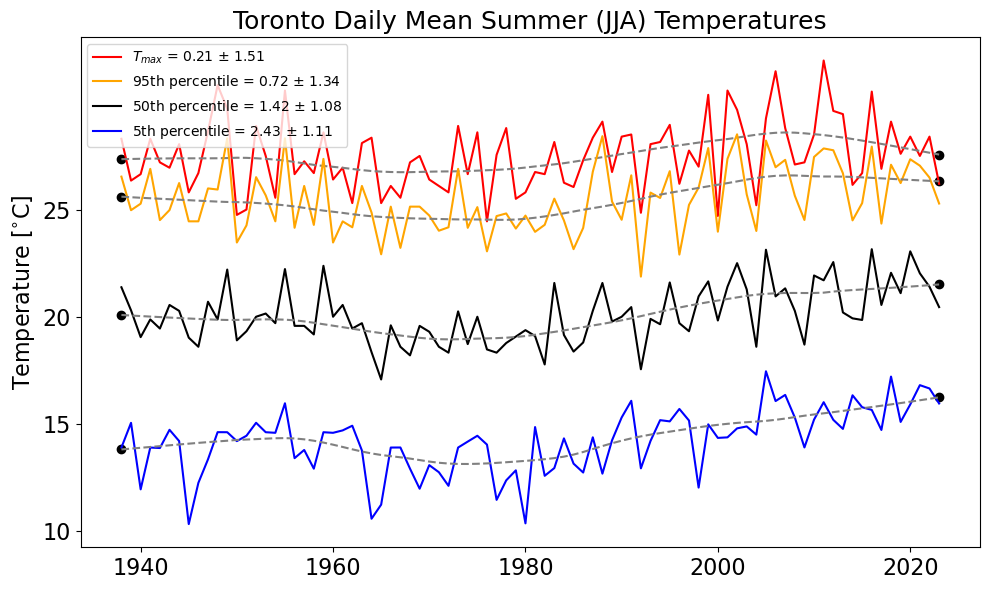

In [11]:
fig, ax = plt.subplots(figsize=(10,6))

first = df_pcts_summ['Year'][0]
last = df_pcts_summ['Year'].iloc[-1]

# Tmax
lowessMaxT = sm.nonparametric.lowess(df_pcts_summ['MaxT'], df_pcts_summ['Year'], frac=0.3)
residMaxT = lowessMaxT[:,1] - df_pcts_summ['MaxT']
spanMaxT = np.round(lowessMaxT[-1][1] - lowessMaxT[0][1], 2)
stdMaxT = np.round(np.std(residMaxT),2)
ax.plot('Year', 'MaxT', data=df_pcts_summ, color="red", label='$T_{max}$ = '+str(spanMaxT)+' $\\pm$ '+str(stdMaxT))
ax.plot(lowessMaxT[:, 0], lowessMaxT[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowessMaxT[0][0], lowessMaxT[0][1], c="black")
ax.scatter(lowessMaxT[-1][0], lowessMaxT[-1][1], c="black")


# P95
lowess95 = sm.nonparametric.lowess(df_pcts_summ['P95'], df_pcts_summ['Year'], frac=0.3)
resid95 = lowess95[:,1] - df_pcts_summ['P95']
span95 = np.round(lowess95[-1][1] - lowess95[0][1], 2)
std95 = np.round(np.std(resid95),2)
ax.plot('Year', 'P95', data=df_pcts_summ, color="orange", label='95th percentile = '+str(span95)+' $\\pm$ '+str(std95))
ax.plot(lowess95[:, 0], lowess95[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess95[0][0], lowess95[0][1], c="black")
ax.scatter(lowess95[-1][0], lowess95[-1][1], c="black")

# P50
lowess50 = sm.nonparametric.lowess(df_pcts_summ['P50'], df_pcts_summ['Year'], frac=0.3)
resid50 = lowess50[:,1] - df_pcts_summ['P50']
span50 = np.round(lowess50[-1][1] - lowess50[0][1], 2)
std50 = np.round(np.std(resid50),2)
ax.plot('Year', 'P50', data=df_pcts_summ, color="black", label='50th percentile = '+str(span50)+' $\\pm$ '+str(std50))
ax.plot(lowess50[:, 0], lowess50[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess50[0][0], lowess50[0][1], c="black")
ax.scatter(lowess50[-1][0], lowess50[-1][1], c="black")


#P05
lowess05 = sm.nonparametric.lowess(df_pcts_summ['P05'], df_pcts_summ['Year'], frac=0.3)
resid05 = lowess05[:,1] - df_pcts_summ['P05']
span05 = np.round(lowess05[-1][1] - lowess05[0][1], 2)
std05 = np.round(np.std(resid05),2)
ax.plot('Year', 'P05', data=df_pcts_summ, color="blue", label='5th percentile = '+str(span05)+' $\\pm$ '+str(std05))
ax.plot(lowess05[:, 0], lowess05[:, 1], linestyle='dashed', color="grey", label='')
ax.scatter(lowess05[0][0], lowess05[0][1], c="black")
ax.scatter(lowess05[-1][0], lowess05[-1][1], c="black")

# other plot stuff
ax.legend(loc="upper left", fontsize=10)
ax.set_title("Toronto Daily Mean Summer (JJA) Temperatures", fontsize=18)
ax.set_ylabel('Temperature [$^{\\circ}$C]', fontsize=16)
ax.set_xlabel("")
plt.xticks(fontsize=16)
plt.yticks(np.arange(10,30,5), fontsize=16)
plt.tight_layout()
plt.show()


# Fit the LOWESS regression model
# lowess = sm.nonparametric.lowess(y, x, frac=0.3)

# # Plot the results
# plt.scatter(x, y, label='data')
# plt.plot(lowess[:, 0], lowess[:, 1], label='LOWESS')

## Plot all percentiles using a loop


In [16]:
cols = df_pcts_summ.columns
cols[2:]

Index(['MeanT', 'MinT', 'MaxT', 'P95', 'P90', 'P80', 'P70', 'P60', 'P50',
       'P40', 'P30', 'P20', 'P10', 'P05'],
      dtype='str')

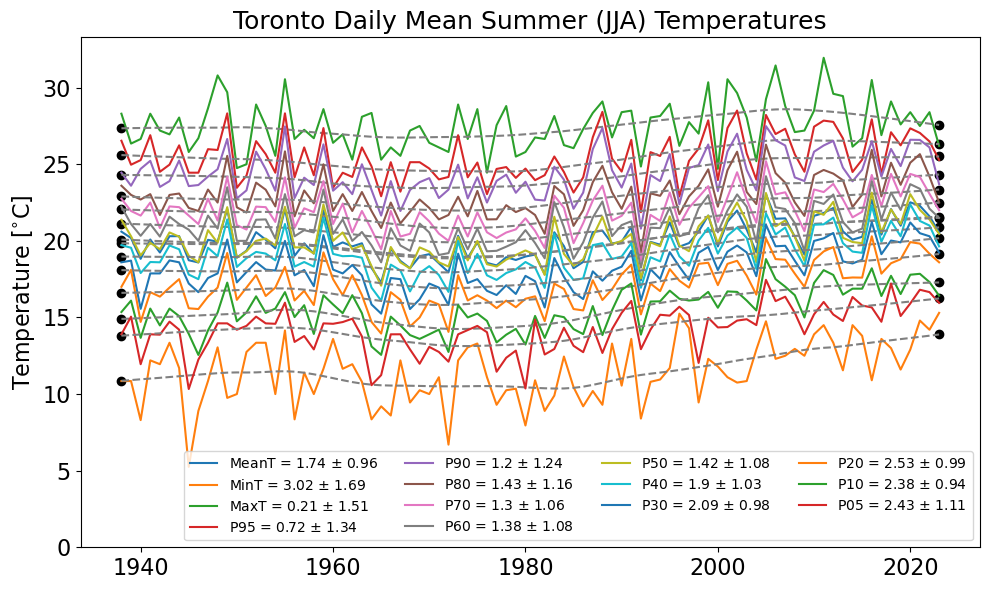

In [22]:
fig, ax = plt.subplots(figsize=(10,6))

first = df_pcts_summ['Year'][0]
last = df_pcts_summ['Year'].iloc[-1]

# list of columns
cols = df_pcts_summ.columns[2:]

# colours maybe?


for i,col in enumerate(cols):

    lowessT = sm.nonparametric.lowess(df_pcts_summ[col], df_pcts_summ['Year'], frac=0.3)
    residT = lowessT[:,1] - df_pcts_summ[col]
    spanT = np.round(lowessT[-1][1] - lowessT[0][1], 2)
    stdT = np.round(np.std(residT),2)
    ax.plot('Year', col, data=df_pcts_summ, label=col + ' = '+str(spanT)+' $\\pm$ '+str(stdT))#, color="red")
    ax.plot(lowessT[:, 0], lowessT[:, 1], linestyle='dashed', color="grey", label='')
    ax.scatter(lowessT[0][0], lowessT[0][1], c="black")
    ax.scatter(lowessT[-1][0], lowessT[-1][1], c="black")
    
    
    # other plot stuff
    ax.legend(loc="lower right", fontsize=10,ncol=4)
    ax.set_title("Toronto Daily Mean Summer (JJA) Temperatures", fontsize=18)
    ax.set_ylabel('Temperature [$^{\\circ}$C]', fontsize=16)
    ax.set_xlabel("")
    plt.xticks(fontsize=16)
    plt.yticks(np.arange(0,35,5), fontsize=16)
    
plt.tight_layout()
plt.show()


## need to compare this with just using ERA5, or maybe CanGridTv4 would work??? annoying to have to merge stations and changes in instumentation seem to be impacting the data

### CanGridT_v4 ReadMe file:
Canadian Gridded Homogenized Surface Air Temperature (CanGridT) Version 4 (with data up to 2024)

**********************
Gridded data for every month and day from January 1948 (1949 for daily data) to December 2024 are available. Both gridded temperature anomalies (GA) and gridded temperature values (GNGA, i.e., non-anomalies) are provided. 

Station anomalies are calculated as departures from the 1961-1990 baseline means and then gridded. Daily and monthly gridded temperature values are produced by adding the gridded climatology to the anomalies at each grid point.   

The gridded temperature values and anomaly values are saved in NetCDF format. A land mask has been applied to set non-land grids as missing values. Each file contains daily values (with leap days excluded) or monthly values for a single year. CanGridT uses the EASE-grid scheme, an equal-area map projection and grid system. Therefore, each grid cell has its own latitude and longitude coordinates.    

****************************
Questions and feedback can be sent to dccah-ahccd@ec.gc.ca


# Read in each year of CanGridTv4 and calculate percentiles for each location then write out the files